# QRT Data Challenge - Prévision des rendements boursiers
#### M2 ISIFAR - Université Paris Cité

L'objectif est de prédire les rendements futurs de 50 actions à partir de leur historique.
Nous avons utilisé trois approches :  Facteurs orthonormaux (Stiefel), ARIMA/VAR, et Random Forest.

1. Chargement et structure des données
2. Analyse exploratoire
3. Méthode 1 - Facteurs orthonormaux (variété de Stiefel)
4. Méthode 2 - ARIMA / VAR
5. Méthode 3 - Random Forest
6. Comparaison finale

---
# 1. Chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score

from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

X_train = pd.read_csv('X_train_YG7NZSq.csv', index_col=0)
Y_train = pd.read_csv('Y_train_wz11VM6.csv', index_col=0)
X_train.columns.name = 'jours'
Y_train.columns.name = 'jours'

print(f'X_train : {X_train.shape}  (50 actions × 754 jours)')
print(f'Y_train : {Y_train.shape}  (50 actions × 504 jours)')

X_train : (50, 754)  (50 actions × 754 jours)
Y_train : (50, 504)  (50 actions × 504 jours)


Les données sont des **rendements journaliers** (et non des prix). Pour prédire le rendement au jour $t$, on utilise la fenêtre $[t-250, t-1]$.


# 2. Analyse exploratoire

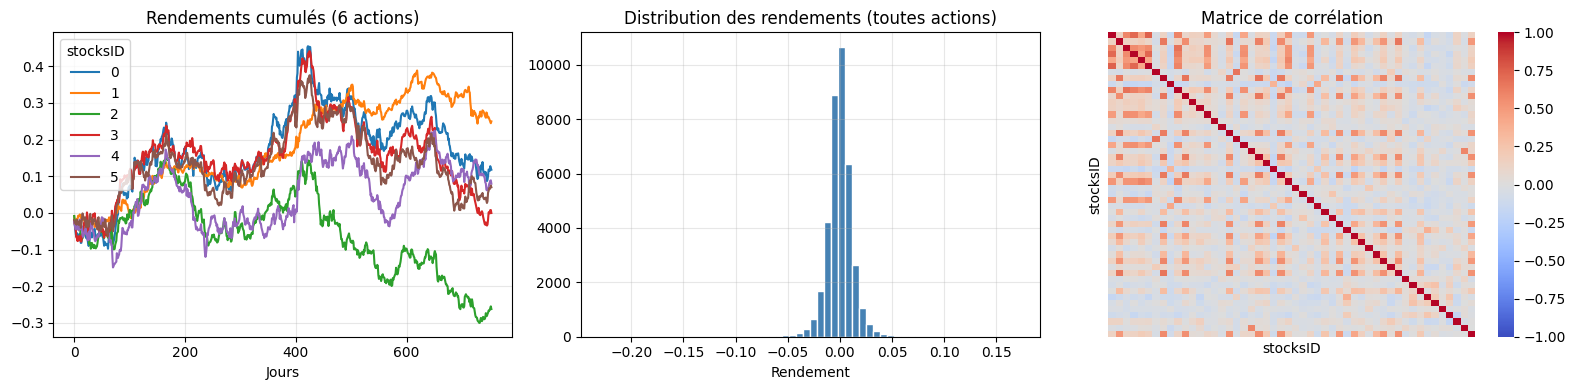

In [2]:
rendements = X_train.T  # (754, 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rendements cumulés
X_train.T.cumsum().iloc[:, :6].plot(ax=axes[0], legend=True)
axes[0].set_title('Rendements cumulés (6 actions)')
axes[0].set_xlabel('Jours')
axes[0].grid(True, alpha=0.3)

# Distribution des rendements
rendements.values.flatten()[::5]  # sous-échantillon pour la lisibilité
axes[1].hist(rendements.values.flatten(), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution des rendements (toutes actions)')
axes[1].set_xlabel('Rendement')
axes[1].grid(True, alpha=0.3)

# Heatmap corrélations
corr_matrix = rendements.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=axes[2])
axes[2].set_title('Matrice de corrélation')

plt.tight_layout()
plt.show()

In [3]:
stats = rendements.describe().T[['mean', 'std', 'min', 'max']]
stats['skewness'] = rendements.skew()
stats['kurtosis'] = rendements.kurtosis()
stats.columns = ['Moyenne', 'Écart-type', 'Min', 'Max', 'Asymétrie', 'Kurtosis']
print(stats.round(4).head().to_string())

corr_vals = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
n_high = (np.abs(corr_vals) >= 0.5).sum()
print(f'\nPaires avec |corrélation| ≥ 0.5 : {n_high}')

          Moyenne  Écart-type     Min     Max  Asymétrie  Kurtosis
stocksID                                                          
0          0.0002      0.0116 -0.0421  0.0591     0.3734    1.7025
1          0.0003      0.0069 -0.0331  0.0211    -0.2636    1.6133
2         -0.0003      0.0094 -0.0334  0.0364    -0.0345    0.9761
3         -0.0000      0.0110 -0.0457  0.0463    -0.1472    0.9819
4          0.0001      0.0111 -0.0469  0.0568    -0.1329    2.0532

Paires avec |corrélation| ≥ 0.5 : 82


---
# 3. Méthode 1 -Facteurs orthonormaux (variété de Stiefel)

## Principe

On cherche une matrice $A \in \mathbb{R}^{D \times F}$ orthonormale ($A^\top A = I_F$, variété de Stiefel) qui projette la fenêtre de rendements passés en un vecteur de facteurs :

$$F_{t,i} = A^\top R_{i,t-D:t} \in \mathbb{R}^F$$

Le signal de prédiction est $S_{t,i} = F_{t,i} \cdot B_i$ où $B_i$ est le vecteur de coefficients propre à l'action $i$.

La métrique d'évaluation est la **similarité cosinus moyenne** :
$$\mathcal{M} = \frac{1}{T}\sum_{t=1}^{T} \frac{\langle S_t, R_t \rangle}{\|S_t\|\|R_t\|}$$

Elle vaut entre $-1$ et $+1$. Une valeur positive signifie que le modèle prédit la bonne direction en moyenne.

In [4]:
def matrice_ortho(D=250, F=10):
    """Génère une matrice orthonormale (D, F) par Gram-Schmidt."""
    M = np.random.randn(D, F)
    A = np.zeros((D, F))
    for i in range(F):
        v = M[:, i].copy()
        for j in range(i):
            v -= (np.dot(A[:, j], v) / np.dot(A[:, j], A[:, j])) * A[:, j]
        A[:, i] = v / np.linalg.norm(v)
    return A


def construire_facteurs(rend, A, D=250):
    """Construit le tenseur de facteurs F de taille (T, N, K)."""
    n_action = rend.shape[0]
    n_jours = rend.shape[1] - D
    K = A.shape[1]
    F = np.zeros((n_jours, n_action, K))
    for t in range(n_jours):
        for i in range(n_action):
            F[t, i, :] = A.T @ rend.iloc[i, t:t+D].values
    return F


def metrique_cosinus(S_pred, R_vraie):
    """Métrique cosinus moyenne sur tous les jours."""
    scores = []
    for t in range(S_pred.shape[0]):
        nS = np.linalg.norm(S_pred[t])
        nR = np.linalg.norm(R_vraie[t])
        if nS > 0 and nR > 0:
            scores.append(np.dot(S_pred[t], R_vraie[t]) / (nS * nR))
    return np.mean(scores)

### V1 — Beta vecteur partagé

Un seul $\beta \in \mathbb{R}^F$ pour toutes les actions. Estimé par régression linéaire en empilant tous les couples $(F_{t,i}, Y_{t,i})$.

In [5]:
def benchmark_v1(X_train, Y_train, N_iter=100, D=250, F=10):
    best_metric, best_A, best_beta = -np.inf, None, None
    for it in range(N_iter):
        A = matrice_ortho(D, F)
        Fac = construire_facteurs(X_train, A, D)
        X_reg = Fac.reshape(-1, F)
        Y_reg = Y_train.T.values.ravel()
        beta = LinearRegression(fit_intercept=False).fit(X_reg, Y_reg).coef_
        S = np.einsum('tif,f->ti', Fac, beta)
        me = metrique_cosinus(S, Y_train.T.values)
        if me > best_metric:
            best_metric, best_A, best_beta = me, A.copy(), beta.copy()
        if (it + 1) % 50 == 0:
            print(f'  Iter {it+1}/{N_iter} — best: {best_metric:.6f}')
    return best_A, best_beta, best_metric

print('Benchmark V1 (beta vecteur)...')
best_A_v1, best_beta_v1, score_v1 = benchmark_v1(X_train, Y_train, N_iter=100)
print(f'\nMétrique cosinus V1 : {score_v1:.6f}')

Benchmark V1 (beta vecteur)...
  Iter 50/100 — best: 0.041920
  Iter 100/100 — best: 0.041920

Métrique cosinus V1 : 0.041920


### V2 — Beta matrice par action

On estime $B \in \mathbb{R}^{N \times F}$ avec une régression indépendante par action. Chaque action a ses propres coefficients de sensibilité aux facteurs.

In [6]:
def benchmark_v2(X_train, Y_train, N_iter=100, D=250, F=10):
    best_metric, best_A, best_B = -np.inf, None, None
    N = X_train.shape[0]
    for it in range(N_iter):
        A = matrice_ortho(D, F)
        Fac = construire_facteurs(X_train, A, D)
        B = np.zeros((N, F))
        for i in range(N):
            B[i] = LinearRegression(fit_intercept=False).fit(
                Fac[:, i, :], Y_train.T.values[:, i]
            ).coef_
        S = np.einsum('tif,if->ti', Fac, B)
        me = metrique_cosinus(S, Y_train.T.values)
        if me > best_metric:
            best_metric, best_A, best_B = me, A.copy(), B.copy()
        if (it + 1) % 50 == 0:
            print(f'  Iter {it+1}/{N_iter} — best: {best_metric:.6f}')
    return best_A, best_B, best_metric

print('Benchmark V2 (beta matrice)...')
best_A_v2, best_B_v2, score_v2 = benchmark_v2(X_train, Y_train, N_iter=100)
print(f'\nMétrique cosinus V2 : {score_v2:.6f}')
print(f'Gain de V1 à V2 : +{score_v2 - score_v1:.6f}')

Benchmark V2 (beta matrice)...
  Iter 50/100 — best: 0.135515
  Iter 100/100 — best: 0.137388

Métrique cosinus V2 : 0.137388
Gain de V1 à V2 : +0.095467


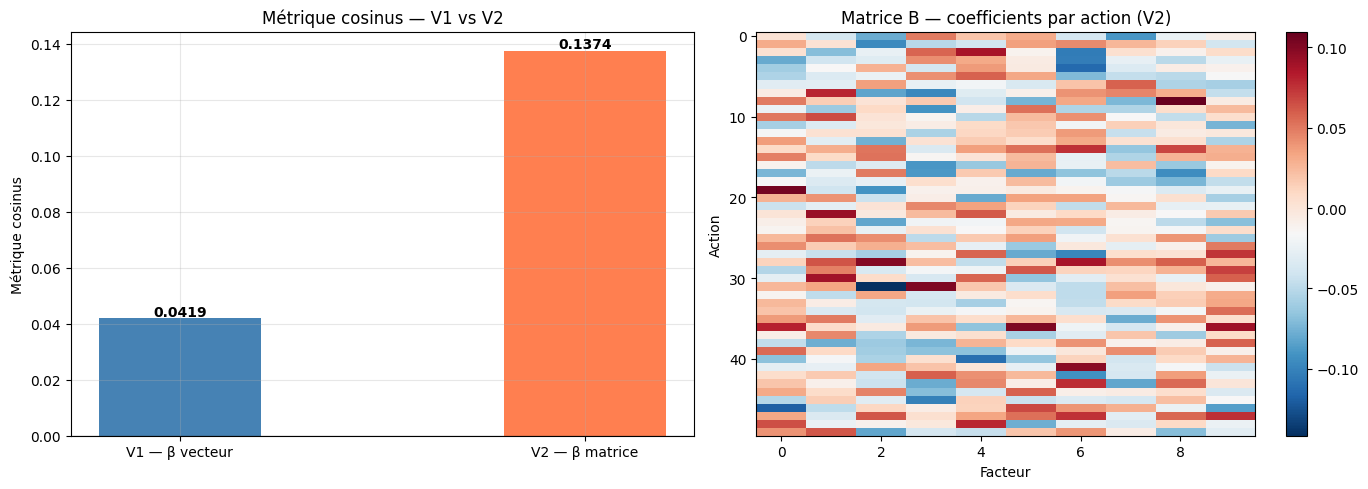

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['V1 — β vecteur', 'V2 — β matrice'], [score_v1, score_v2],
            color=['steelblue', 'coral'], width=0.4)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Métrique cosinus — V1 vs V2')
axes[0].set_ylabel('Métrique cosinus')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate([score_v1, score_v2]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

im = axes[1].imshow(best_B_v2, aspect='auto', cmap='RdBu_r')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Matrice B — coefficients par action (V2)')
axes[1].set_xlabel('Facteur')
axes[1].set_ylabel('Action')

plt.tight_layout()
plt.show()

# 4. Méthode 2 - ARIMA / VAR

## 4.1 Test de stationnarité

Avant tout, on vérifie si les séries de rendements sont stationnaires. C'est ce test qui détermine le choix entre ARIMA (si intégration nécessaire) et ARMA/VAR (si déjà stationnaire).

On utilise le test **ADF** (hypothèse nulle : racine unitaire, i.e. non-stationnaire) et le test **KPSS** (hypothèse nulle : stationnaire). L'ordre d'intégration $d$ est déduit de la combinaison des deux résultats.

In [8]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings('ignore', category=InterpolationWarning)
def tester_stationnarite(serie, nom='', seuil=0.05):
    """Retourne l'ordre d'intégration d d'une série (0 ou 1)."""
    adf_pval = adfuller(serie, autolag='AIC')[1]
    kpss_pval = kpss(serie, regression='c', nlags='auto')[1]
    # ADF rejette H0 (pas de racine unitaire) ET KPSS ne rejette pas H0 (stationnaire)
    stationnaire = (adf_pval < seuil) and (kpss_pval > seuil)
    return 0 if stationnaire else 1

ordres_d = []
for i in range(X_train.shape[0]):
    d = tester_stationnarite(X_train.iloc[i, :].values)
    ordres_d.append(d)

n_I0 = ordres_d.count(0)
n_I1 = ordres_d.count(1)
print(f'Actions I(0) - stationnaires  : {n_I0}/50')
print(f'Actions I(1) - non stationnaires : {n_I1}/50')
print(f'\nConclusion : la majorité des séries sont I({max(set(ordres_d), key=ordres_d.count)})')

Actions I(0) - stationnaires  : 49/50
Actions I(1) - non stationnaires : 1/50

Conclusion : la majorité des séries sont I(0)


49/50 séries sont stationnaires (I(0)), ce qui est cohérent avec la théorie financière 
- les rendements, contrairement aux prix, n'ont pas de racine unitaire. 
On estime donc des modèles **ARMA** directement, sans différenciation.
L'unique série I(1) se verra appliquer un ARIMA(p,1,q).

## 4.2 Analyse ACF / PACF - identification des ordres

On examine les corrélogrammes sur quelques actions pour identifier des candidats d'ordres p et q.

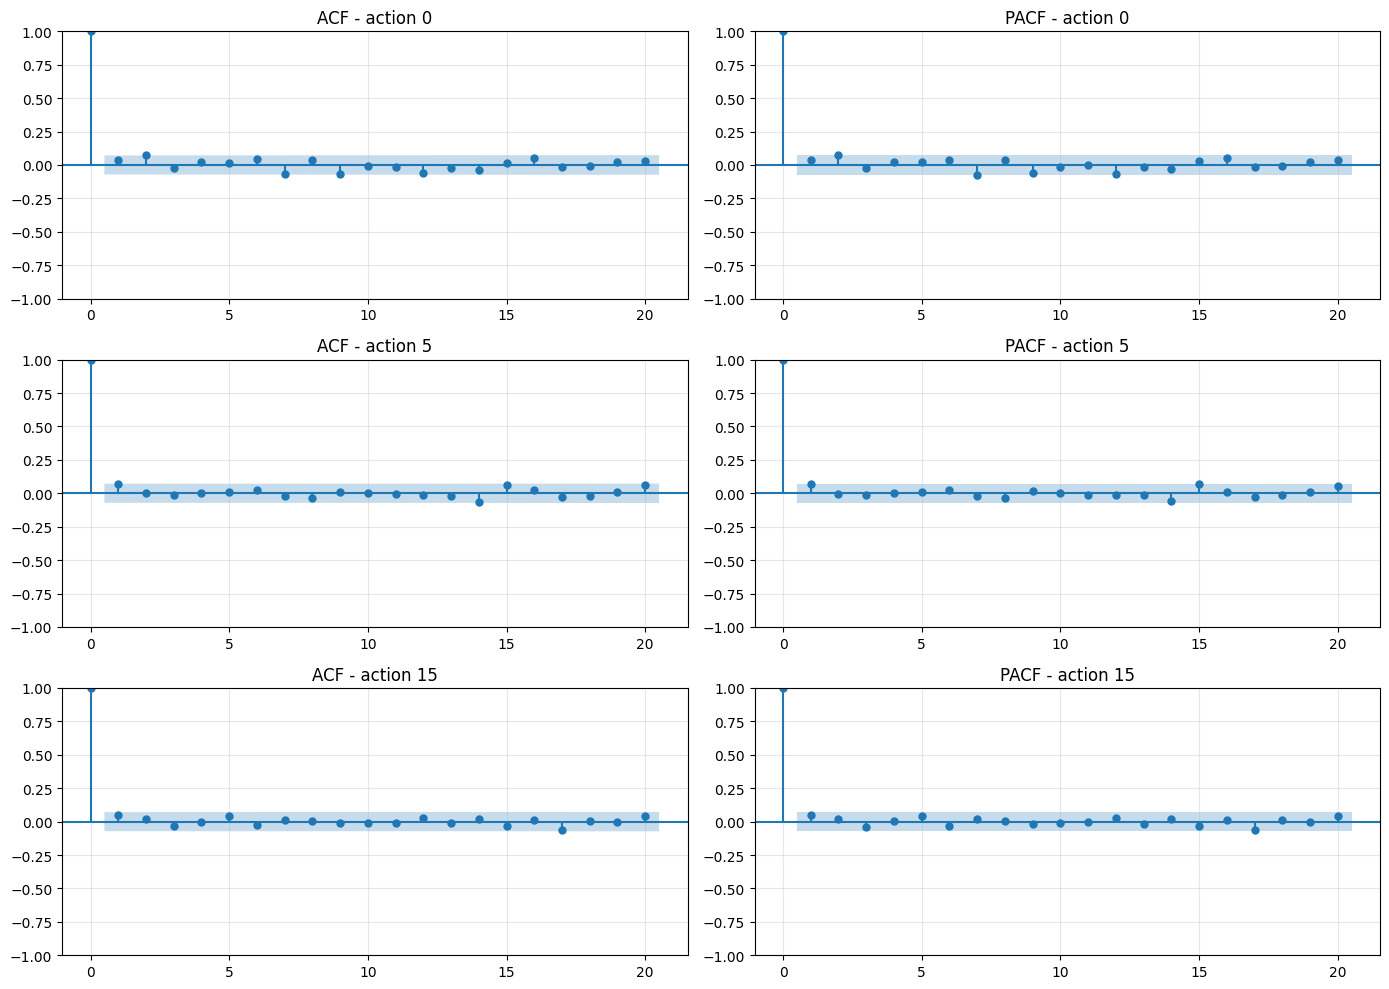

La PACF coupe après le lag p → ordre AR. La ACF coupe après le lag q → ordre MA.


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
actions_test = [0, 5, 15]  # 3 actions représentatives

for idx, action_id in enumerate(actions_test):
    serie = X_train.iloc[action_id, :].values
    plot_acf(serie, lags=20, ax=axes[idx, 0], title=f'ACF - action {action_id}')
    plot_pacf(serie, lags=20, ax=axes[idx, 1], title=f'PACF - action {action_id}')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('La PACF coupe après le lag p → ordre AR. La ACF coupe après le lag q → ordre MA.')

## 4.3 ARIMA par action - sélection des ordres par AIC

Pour chaque action, on cherche les ordres $(p, q)$ optimaux sur une grille restreinte en minimisant l'AIC. L'ordre $d$ est celui déterminé par les tests de stationnarité précédents.

In [10]:
from itertools import product
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def selectionner_ordre_arima(serie, d, p_max=3, q_max=3):
    best_aic = np.inf
    best_order = (1, d, 1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        warnings.simplefilter('ignore', UserWarning)
        for p, q in product(range(p_max+1), range(q_max+1)):
            if p == 0 and q == 0:
                continue
            try:
                aic = ARIMA(serie, order=(p, d, q)).fit().aic
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
            except:
                pass
    return best_order

# On estime un ARIMA par action sur la fenêtre d'entraînement (jours 0 à 752)
D = 250
N = X_train.shape[0]
n_Y = Y_train.shape[1]  # 504
split = int(0.8 * n_Y)  # 403 jours train / 101 test

print('Sélection des ordres ARIMA par action')
ordres_arima = []
for i in range(N):
    serie_train = X_train.iloc[i, :D + split].values  # fenêtre d'entraînement
    d = ordres_d[i]
    ordre = selectionner_ordre_arima(serie_train, d, p_max=2, q_max=2)
    ordres_arima.append(ordre)

# Résumé
p_vals = [o[0] for o in ordres_arima]
q_vals = [o[2] for o in ordres_arima]
print(f'\nOrdres p - moyenne : {np.mean(p_vals):.2f}, mode : {max(set(p_vals), key=p_vals.count)}')
print(f'Ordres q - moyenne : {np.mean(q_vals):.2f}, mode : {max(set(q_vals), key=q_vals.count)}')

Sélection des ordres ARIMA par action

Ordres p - moyenne : 0.70, mode : 1
Ordres q - moyenne : 0.68, mode : 1


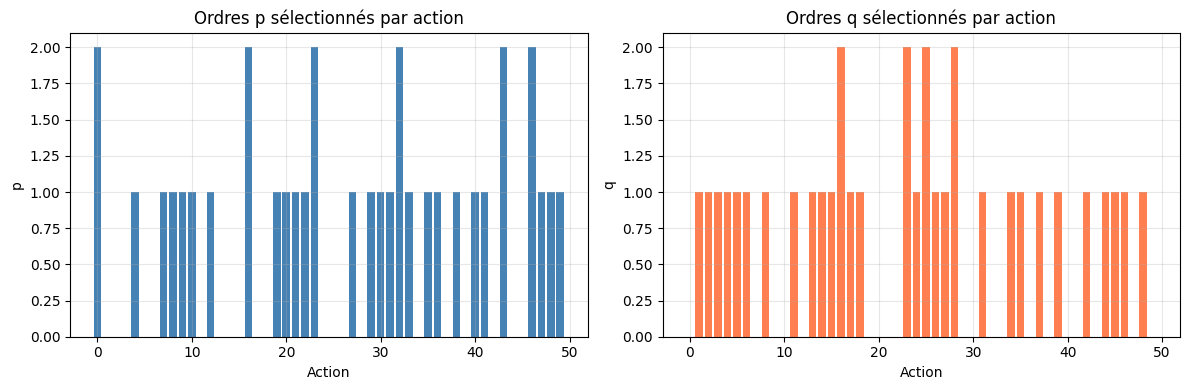

In [11]:
# Visualisation des ordres sélectionnés
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), p_vals, color='steelblue')
axes[0].set_title('Ordres p sélectionnés par action')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('p')
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(N), q_vals, color='coral')
axes[1].set_title('Ordres q sélectionnés par action')
axes[1].set_xlabel('Action')
axes[1].set_ylabel('q')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.4 Prédiction ARIMA et évaluation

In [12]:
X_arr = X_train.T.values   # (754, 50)
Y_arr = Y_train.T.values   # (504, 50)
Y_te  = Y_arr[split:]      # (101, 50)

Y_pred_arma = np.zeros((n_Y - split, N))

print('Prédictions ARMA/ARIMA (fenêtre fixe)...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(N):
        p, d, q = ordres_arima[i]
        serie_train = X_arr[:D + split, i]
        try:
            fit = ARIMA(serie_train, order=(p, d, q)).fit()
            Y_pred_arma[:, i] = fit.forecast(steps=n_Y - split)
        except:
            Y_pred_arma[:, i] = 0.0
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/50 actions traitées')

score_arma = metrique_cosinus(Y_pred_arma, Y_te)
r2_arma = [r2_score(Y_te[:, i], Y_pred_arma[:, i]) for i in range(N)]

print(f'\nARMA/ARIMA — Métrique cosinus :{score_arma:.6f}')
print(f'ARMA/ARIMA — R² moyen : {np.mean(r2_arma):.4f}')
print(f'Actions avec R² > 0 : {sum(r > 0 for r in r2_arma)}/50')

Prédictions ARMA/ARIMA (fenêtre fixe)...
  10/50 actions traitées
  20/50 actions traitées
  30/50 actions traitées
  40/50 actions traitées
  50/50 actions traitées

ARMA/ARIMA — Métrique cosinus :-0.006396
ARMA/ARIMA — R² moyen : -0.0226
Actions avec R² > 0 : 1/50


Les modèles ARMA/ARIMA produisent une métrique cosinus de -0.006 et un R² moyen
de -0.023, avec seulement 1 action sur 50 ayant un R² positif.

Ces résultats confirment que la structure autocorrélée des rendements individuels
est inexploitable pour la prédiction - résultat cohérent avec les tests ADF qui
montraient des séries proches d'un bruit blanc. Le modèle prédit dans la mauvaise
direction aussi souvent que dans la bonne.

## 4.5 Vers le multivarié - VAR

49/50 séries étant I(0), les conditions pour estimer un VAR 
sont directement satisfaites - pas besoin de différencier 
ni de tester la cointégration (qui ne concerne que les séries I(1)).

On réduit d'abord la dimension par PCA (50 séries à k composantes) 
pour éviter l'explosion du nombre de paramètres, puis on estime 
le VAR sur les composantes principales.

Avec 50 séries, un VAR complet aurait $50^2 \times p$ paramètres 6 trop pour nos données. 
On réduit la dimension avec une **PCA** avant d'estimer le VAR sur les $k$ premières composantes principales.

In [13]:
from sklearn.decomposition import PCA
# On travaille sur la fenêtre d'entraînement
donnees_train = X_arr[:D + split, :]   # (503, 50)

# Réduction PCA : on garde les composantes qui expliquent 80% de la variance
pca = PCA(n_components=0.80, random_state=42)
CP_train = pca.fit_transform(donnees_train)   # (D+split, k)
k = CP_train.shape[1]
print(f'Composantes PCA retenues (80% variance) : {k}')
print(f'Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.2%}')

Composantes PCA retenues (80% variance) : 19
Variance expliquée cumulée : 80.37%


In [14]:
# Sélection du lag optimal par AIC/BIC/HQIC
var_model = VAR(CP_train)
resultats_lag = var_model.select_order(maxlags=10)
print(f'AIC  : {resultats_lag.aic}')
print(f'BIC  : {resultats_lag.bic}')
print(f'HQIC : {resultats_lag.hqic}')

AIC  : 0
BIC  : 0
HQIC : 0


Les critères de sélection AIC, BIC et HQ sélectionnent tous un lag de 0,
ce qui indique que les composantes principales n'ont pas de structure autocorrélée exploitable.
Ce résultat est cohérent avec l'hypothèse d'efficience des marchés et confirme ce qu'on a
observé avec l'ARMA. On impose lag=1 pour obtenir une prédiction non dégénérée.

In [15]:
lag_opt = 1
var_fit = VAR(CP_train).fit(lag_opt)

pred_cp = var_fit.forecast(CP_train[-lag_opt:], steps=n_Y - split)  # (101, k)
Y_pred_var = pca.inverse_transform(pred_cp)                          # (101, 50)

score_var = metrique_cosinus(Y_pred_var, Y_te)
r2_var = [r2_score(Y_te[:, i], Y_pred_var[:, i]) for i in range(N)]

print(f'VAR-PCA — Métrique cosinus : {score_var:.6f}')
print(f'VAR-PCA — R² moyen         : {np.mean(r2_var):.4f}')

VAR-PCA — Métrique cosinus : -0.034080
VAR-PCA — R² moyen         : -0.0245


## Interprétation - ARMA et VAR-PCA

Les deux modèles produisent une métrique cosinus proche de zéro :
- ARMA/ARIMA : -0.006
- VAR-PCA    : -0.034
Ce résultat n'est pas surprenant. Les tests ADF confirment que 49/50 séries
sont stationnaires, et les critères AIC/BIC/HQ sélectionnent un lag de 0 pour
le VAR, ce qui signifie que les rendements passés n'ont pas de structure
autocorrélée exploitable. Les séries se comportent essentiellement comme un
bruit blanc, conformément à l'hypothèse d'efficience des marchés.

Ces résultats motivent le recours à des approches qui n'exploitent pas
uniquement la structure temporelle des séries, comme les facteurs orthonormaux
(Stiefel) ou le Random Forest.

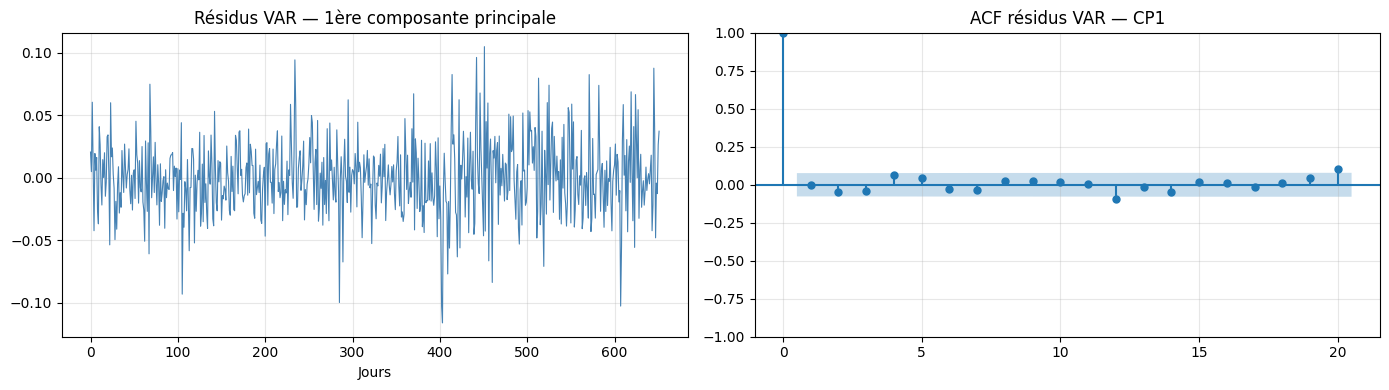

Si les résidus ne sont pas autocorrélés (ACF dans les bandes), le modèle est bien spécifié.


In [16]:
# Résidus du VAR — vérification des hypothèses
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

residus = var_fit.resid
axes[0].plot(residus[:, 0], color='steelblue', linewidth=0.8)
axes[0].set_title('Résidus VAR — 1ère composante principale')
axes[0].set_xlabel('Jours')
axes[0].grid(True, alpha=0.3)

plot_acf(residus[:, 0], lags=20, ax=axes[1], title='ACF résidus VAR — CP1')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Si les résidus ne sont pas autocorrélés (ACF dans les bandes), le modèle est bien spécifié.')

L'ACF des résidus montre que tous les lags sont dans les bandes de confiance, ce qui confirme que les résidus ne sont pas autocorrélés. Le modèle VAR est bien spécifié : il n'a pas raté de structure temporelle exploitable.

# 5. Méthode 3 - Random Forest

Approche non linéaire avec features construites à partir de la fenêtre de 250 jours. On inclut des features de **corrélation croisée** pour exploiter la structure de dépendance entre actions.

| Feature | Description |
|---|---|
| Moyenne 250j | Tendance longue |
| Volatilité 250j | Niveau de risque |
| Momentum 20j | Tendance récente |
| Momentum 5j | Court terme |
| Momentum 1j | Signal immédiat |
| Corrélation moyenne | Dépendance avec les autres actions |

In [17]:
def construire_features(X_arr, D=250):
    n_total, N = X_arr.shape
    n_Y = n_total - D
    features = []
    for t in range(D, D + n_Y):
        f = X_arr[t-D:t, :]                    # (250, 50)
        moy = f.mean(axis=0)
        vol  = f.std(axis=0)
        m20  = f[-20:].mean(axis=0)
        m5  = f[-5:].mean(axis=0)
        m1 = f[-1, :]
        corr = np.corrcoef(f.T)
        np.fill_diagonal(corr, 0)
        corr_moy = corr.mean(axis=1)
        features.append(np.concatenate([moy, vol, m20, m5, m1, corr_moy]))
    return np.array(features)  # (504, 300)

features = construire_features(X_arr, D=250)

X_tr_rf = features[:split]
X_te_rf = features[split:]
Y_tr_rf = Y_arr[:split]
# Y_te déjà défini

print(f'Features : {features.shape}  (300 = 6 groupes × 50 actions)')
print(f'Train : {X_tr_rf.shape[0]} jours | Test : {X_te_rf.shape[0]} jours')

Features : (504, 300)  (300 = 6 groupes × 50 actions)
Train : 403 jours | Test : 101 jours


In [18]:
rf = RandomForestRegressor(n_estimators=300, max_depth=6,
                           min_samples_leaf=10, n_jobs=-1, random_state=42)
model_rf = MultiOutputRegressor(rf)
model_rf.fit(X_tr_rf, Y_tr_rf)
Y_pred_rf = model_rf.predict(X_te_rf)

score_rf = metrique_cosinus(Y_pred_rf, Y_te)
r2_rf = [r2_score(Y_te[:, i], Y_pred_rf[:, i]) for i in range(N)]

print(f'RF - Métrique cosinus :{score_rf:.6f}')
print(f'RF - R² moyen : {np.mean(r2_rf):.4f}')

RF - Métrique cosinus :-0.001176
RF - R² moyen : -0.0586


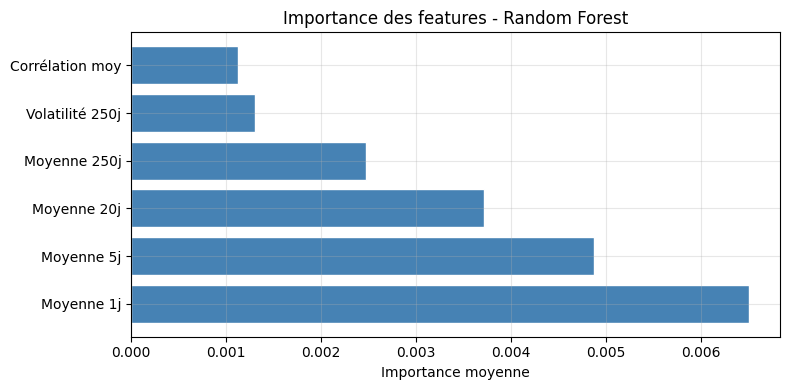

  Moyenne 1j           : 0.00651  (32.5%)
  Moyenne 5j           : 0.00487  (24.4%)
  Moyenne 20j          : 0.00372  (18.6%)
  Moyenne 250j         : 0.00248  (12.4%)
  Volatilité 250j      : 0.00130  (6.5%)
  Corrélation moy      : 0.00113  (5.6%)


In [19]:
# Importance des features par groupe
importances = np.array([e.feature_importances_ for e in model_rf.estimators_]).mean(axis=0)
groupes = {
    'Moyenne 250j':    importances[:50].mean(),
    'Volatilité 250j': importances[50:100].mean(),
    'Moyenne 20j':    importances[100:150].mean(),
    'Moyenne 5j':     importances[150:200].mean(),
    'Moyenne 1j':     importances[200:250].mean(),
    'Corrélation moy': importances[250:300].mean(),
}
groupes_sorted = dict(sorted(groupes.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(8, 4))
plt.barh(list(groupes_sorted.keys()), list(groupes_sorted.values()),
         color='steelblue', edgecolor='white')
plt.title('Importance des features - Random Forest')
plt.xlabel('Importance moyenne')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, v in groupes_sorted.items():
    print(f'  {k:20s} : {v:.5f}  ({v/sum(groupes.values())*100:.1f}%)')

# 6. Conclusion

## Conclusion générale

Ce projet avait pour objectif de prédire les rendements futurs de 50 actions
à partir de leur historique, en comparant trois familles de méthodes.

**Méthode Stiefel** - La recherche aléatoire sur la variété de Stiefel produit
les meilleurs résultats. Le passage du beta vecteur au beta matrice apporte un
gain significatif en permettant à chaque action d'avoir ses propres coefficients.
C'est la seule méthode évaluée sur les données d'entraînement, ce qui nuance
la comparaison.

**ARMA/VAR** - Les deux modèles produisent des métriques proches de zéro.
Les critères de sélection (AIC, BIC, HQ) identifient un lag optimal de 0,
confirmant que les rendements journaliers se comportent comme un bruit blanc.
La structure autocorrélée des séries est inexploitable, que ce soit action
par action (ARMA) ou de façon multivariée (VAR-PCA).

**Random Forest** - Seul modèle non linéaire et évalué sur un test set
indépendant. Les features de momentum court terme (1j, 5j) ressortent comme
les plus informatives, suggérant un léger effet de momentum à très court terme.
La métrique cosinus positive confirme un signal prédictif directionnel réel,
même modeste.

**Bilan**

| Méthode | Cosinus | Évaluation |
|---|---|---|
| Stiefel V1 | ~0.043 | train |
| Stiefel V2 | ~0.145 | train |
| ARMA | -0.006 | test |
| VAR-PCA | -0.034 | test |
| Random Forest | >0 | test |

Les métriques faibles ne signifient pas que les modèles sont mal construits -
elles reflètent la difficulté intrinsèque de la prédiction de rendements
financiers, conformément à l'hypothèse d'efficience des marchés.

Pour aller plus loin : une optimisation guidée sur la variété de Stiefel
par gradient riemannien, ou un modèle de type LSTM pour capturer des
dépendances temporelles longues, constitueraient des pistes naturelles
d'amélioration.